# Sentiment Analysis LSTM + Evaluasi Detail + Visualisasi
Dataset: Instagram Comments (Bahasa Indonesia + Emoji)


In [36]:
!pip install pandas numpy scikit-learn tensorflow emoji matplotlib

In [37]:
import pandas as pd
import numpy as np
import re, random
import emoji
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

## Load & Prepare Data

In [ ]:
df = pd.read_csv('../dataset/Data_Gabungan.csv')
df = df[['Isi_Komentar','Sentimen']].dropna()

df['label_enc'] = df['Sentimen'].apply(lambda x: 0 if x==-1 else (1 if x==0 else 2))

## PREPROCESSING

In [39]:
def clean_text(text):
    text = str(text).lower()
    text = emoji.demojize(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s:]', ' ', text)
    return text

df['clean'] = df['Isi_Komentar'].apply(clean_text)

## AUGMENTASI

In [40]:
def random_swap(text):
    words = text.split()
    if len(words) < 2:
        return text
    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]
    return ' '.join(words)

def random_deletion(text, p=0.2):
    words = text.split()
    if len(words) == 1:
        return text
    new_words = [w for w in words if random.random() > p]
    return ' '.join(new_words)

df_pos = df[df['label_enc'] == 2]

aug1 = df_pos.copy()
aug1['clean'] = aug1['clean'].apply(random_swap)

aug2 = df_pos.copy()
aug2['clean'] = aug2['clean'].apply(random_deletion)

df = pd.concat([df, aug1, aug2])

## Tokenization

In [41]:
tokenizer = Tokenizer(num_words=12000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean'])

seq = tokenizer.texts_to_sequences(df['clean'])
pad = pad_sequences(seq, maxlen=100, padding='post')

## Split Data

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    pad, df['label_enc'], test_size=0.2, random_state=42
)

## Model BiLSTM

In [43]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

model = Sequential([
    Embedding(12000, 128),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=0.0005)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=2,
#     restore_best_weights=True
# )

{0: np.float64(1.2588439460686156), 1: np.float64(1.0530429927414853), 2: np.float64(0.7961837217156366)}


## Training

In [44]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights,
    # callbacks=[early_stop]
)

Epoch 1/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 93s 151ms/step - accuracy: 0.6233 - loss: 0.8461 - val_accuracy: 0.7402 - val_loss: 0.6400
Epoch 2/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 77s 145ms/step - accuracy: 0.7831 - loss: 0.5690 - val_accuracy: 0.7943 - val_loss: 0.5193
Epoch 3/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 75s 141ms/step - accuracy: 0.8491 - loss: 0.4326 - val_accuracy: 0.8059 - val_loss: 0.5300
Epoch 4/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 83s 144ms/step - accuracy: 0.8794 - loss: 0.3494 - val_accuracy: 0.8065 - val_loss: 0.5445
Epoch 5/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 82s 144ms/step - accuracy: 0.9018 - loss: 0.2971 - val_accuracy: 0.8070 - val_loss: 0.5755
Epoch 6/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 74s 140ms/step - accuracy: 0.9123 - loss: 0.2627 - val_accuracy: 0.7927 - val_loss: 0.6391
Epoch 7/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 77s 144ms/step - accuracy: 0.9241 - loss: 0.2334 - val_accuracy: 0.8086 - val_loss: 0.6487
Epoch 8/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 76s 144ms/step - accuracy: 0.9284 - loss: 0

## Evaluasi Detail

In [45]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=['Negatif','Netral','Positif'],
    digits=4
))

148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step
Confusion Matrix:
[[ 794  315  121]
 [ 310 1017  127]
 [  67   92 1872]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.6781    0.6455    0.6614      1230
      Netral     0.7142    0.6994    0.7067      1454
     Positif     0.8830    0.9217    0.9020      2031

    accuracy                         0.7811      4715
   macro avg     0.7584    0.7556    0.7567      4715
weighted avg     0.7775    0.7811    0.7790      4715



## Hitung TP, FP, FN per kelas

In [46]:
for i, label in enumerate(['Negatif','Netral','Positif']):
    TP = cm[i][i]
    FP = cm[:,i].sum() - TP
    FN = cm[i,:].sum() - TP
    print(f"{label} -> TP:{TP}, FP:{FP}, FN:{FN}")

Negatif -> TP:794, FP:377, FN:436
Netral -> TP:1017, FP:407, FN:437
Positif -> TP:1872, FP:248, FN:159


## Visualisasi Training

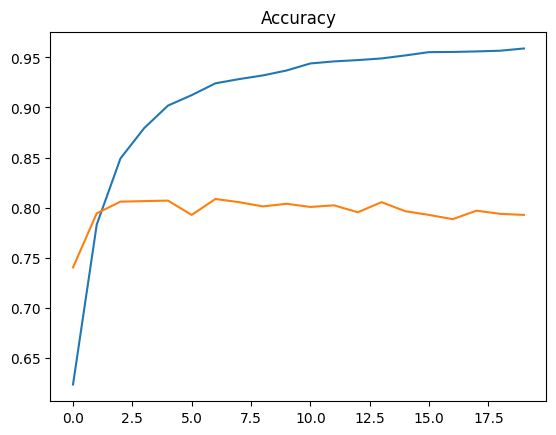

In [47]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.show()

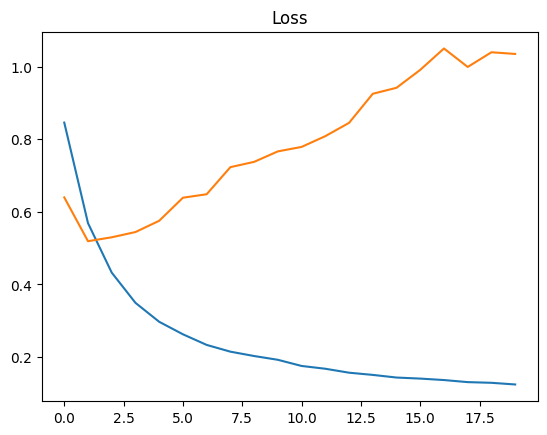

In [48]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.show()